# Instituto Tecnológico y de Estudios Superiores de Monterrey
## Escuela de Ingenierías
## Maestría en Inteligencia Artificial Aplicada
## Proyecto Integrador (TC5035 - Grupo 10)

---

# Avance 5 – Modelo Final
## Proyecto Integrador TC5035 – Grupo 28

**Integrantes del grupo:**

- Carolina Gómez Fernández – A01305369
- Jorge Eduardo Reyes de la Rosa – A00282698
- Enrique Jiménez Téllez – A01796026

## Objetivos del avance

- **3.5.** Mejorar el rendimiento predictivo aprovechando las fortalezas de distintos modelos de ensamble.
- **3.6.** Evaluar la calidad de las predicciones del modelo final usando datos no vistos.

Este cuaderno unifica las versiones revisadas del Avance 5. Integra modelos individuales de la fase previa, modelos de ensamble homogéneos y heterogéneos, optimización de hiperparámetros, tabla comparativa final con tiempos de entrenamiento y gráficos interpretables del modelo seleccionado.

## 1. Configuración inicial e importación de librerías

Se centralizan las librerías, constantes y parámetros generales para facilitar la ejecución completa del cuaderno.  
La métrica principal será **F1 Test**, porque el problema busca identificar estudiantes en riesgo manteniendo equilibrio entre **precision** y **recall**.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    EN_COLAB = True
except Exception:
    EN_COLAB = False

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    VotingClassifier,
    StackingClassifier
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    classification_report,
    average_precision_score
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
TARGET = "Target_Reprobado"
METRICA_PRINCIPAL = "F1 Test"
POS_LABEL = 1

# Cambiar a False si se desea una búsqueda más amplia de hiperparámetros.
MODO_RAPIDO = True

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

print("Configuración lista.")

Configuración lista.


## 2. Carga de datos

Se cargan los archivos generados en la fase de ingeniería de características.  
Mantener los mismos conjuntos de entrenamiento y prueba permite comparar este avance con los modelos individuales del Avance 4 bajo condiciones equivalentes.

In [ ]:
drive.mount("/content/drive")

ruta_base = "/content/drive/MyDrive/Proyecto Integrador/Versiones Finales/Avance 5"

train_path = os.path.join(ruta_base, "dataset_train_feature_engineering.csv")
test_path = os.path.join(ruta_base, "dataset_test_feature_engineering.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

print("Dimensiones train:", train_df.shape)
print("Dimensiones test:", test_df.shape)

display(train_df.head())

Mounted at /content/drive
Dimensiones train: (1192, 17)
Dimensiones test: (298, 17)


,Año_lectivo,Promedio de ingreso,Evaluación_1,Evaluación_2,Evaluación_3,Tareas_y_Pruebas_Cortas,Promedio_Evaluaciones,Desviacion_Evaluaciones,Diferencia_Eval3_Eval1,Ratio_Tareas_vs_Evaluaciones,Nivel_Distancia_Muy_cerca,Nivel_Promedio_Ingreso_Alto,Nivel_Promedio_Ingreso_Bajo,Nivel_Promedio_Ingreso_Muy_alto,Nivel_Promedio_Ingreso_Muy_bajo,Profesor,Target_Reprobado
0,-1.547406,1.815152,-0.271123,-1.300449,0.625233,1.985579,-0.240928,1.193730,0.913813,0.587437,1.0,1.0,0.0,0.0,0.0,-1.898955,1
1,0.222189,-1.140500,0.365479,0.015388,1.019268,-0.507075,0.641470,0.567877,0.876248,-0.443776,0.0,0.0,0.0,0.0,1.0,0.630560,1
2,-0.367676,0.930930,0.458188,-1.095763,0.812711,0.822483,0.172526,1.284042,0.571968,-0.015749,0.0,1.0,0.0,0.0,0.0,-0.453518,1
3,1.401919,-1.447608,-0.716126,0.161592,-0.959205,-0.357686,-0.666482,0.015830,-0.541848,-0.049357,0.0,0.0,0.0,0.0,1.0,0.269200,1
4,1.401919,2.192338,1.539792,1.565151,1.205917,0.472487,1.684493,-0.582136,0.195374,-0.372890,0.0,0.0,0.0,1.0,0.0,-1.176236,0


## 3. Funciones auxiliares de evaluación

Se define una única función de evaluación para todos los modelos.  
Esto evita comparaciones injustas y permite registrar métricas relevantes en datos de entrenamiento y prueba, además del tiempo de entrenamiento.

In [ ]:
def obtener_score_positivo(modelo, X):
    """Devuelve la probabilidad o score de la clase positiva cuando el modelo lo permite."""
    if hasattr(modelo, "predict_proba"):
        return modelo.predict_proba(X)[:, 1]
    if hasattr(modelo, "decision_function"):
        return modelo.decision_function(X)
    return None


def evaluar_modelo(nombre, modelo, X_train, y_train, X_test, y_test, tiempo_extra=0):
    """Entrena un modelo y calcula métricas comparables en train y test."""
    inicio = time.time()
    modelo.fit(X_train, y_train)
    tiempo_fit = time.time() - inicio
    tiempo_total = tiempo_fit + tiempo_extra

    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    y_score_train = obtener_score_positivo(modelo, X_train)
    y_score_test = obtener_score_positivo(modelo, X_test)

    roc_train = roc_auc_score(y_train, y_score_train) if y_score_train is not None else np.nan
    roc_test = roc_auc_score(y_test, y_score_test) if y_score_test is not None else np.nan
    avg_precision = average_precision_score(y_test, y_score_test) if y_score_test is not None else np.nan

    f1_train = f1_score(y_train, y_pred_train, zero_division=0)
    f1_test = f1_score(y_test, y_pred_test, zero_division=0)

    resultado = {
        "Modelo": nombre,
        "Accuracy Train": accuracy_score(y_train, y_pred_train),
        "Accuracy Test": accuracy_score(y_test, y_pred_test),
        "Balanced Accuracy Test": balanced_accuracy_score(y_test, y_pred_test),
        "Precision Test": precision_score(y_test, y_pred_test, zero_division=0),
        "Recall Test": recall_score(y_test, y_pred_test, zero_division=0),
        "F1 Train": f1_train,
        "F1 Test": f1_test,
        "ROC-AUC Train": roc_train,
        "ROC-AUC Test": roc_test,
        "Average Precision Test": avg_precision,
        "Diferencia F1 Train-Test": f1_train - f1_test,
        "Tiempo entrenamiento (seg)": tiempo_total
    }

    return resultado, modelo, y_pred_test, y_score_test


def registrar_resultado(nombre, modelo, resultados, modelos_entrenados, predicciones, scores, tiempo_extra=0):
    print("=" * 80)
    print("Entrenando/evaluando:", nombre)
    print("=" * 80)

    resultado, modelo_entrenado, y_pred, y_score = evaluar_modelo(
        nombre, modelo, X_train, y_train, X_test, y_test, tiempo_extra=tiempo_extra
    )

    resultados.append(resultado)
    modelos_entrenados[nombre] = modelo_entrenado
    predicciones[nombre] = y_pred
    scores[nombre] = y_score

    print({k: round(v, 4) if isinstance(v, (int, float, np.floating)) else v for k, v in resultado.items()})
    return resultado

## 4. Modelos individuales de referencia

Se incluyen los mejores modelos individuales trabajados en la fase previa para cumplir con la comparación solicitada en la rúbrica.  
Estos modelos también se usan como base para los ensambles heterogéneos.

In [ ]:
modelo_rf_individual = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=2,
    min_samples_split=5,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

modelo_dt_individual = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=2,
    min_samples_split=5,
    criterion="entropy",
    class_weight="balanced",
    random_state=RANDOM_STATE
)

modelo_knn_individual = KNeighborsClassifier(
    n_neighbors=7,
    weights="distance",
    metric="manhattan"
)

modelos_individuales = {
    "Random Forest Individual": modelo_rf_individual,
    "Árbol de Decisión Individual": modelo_dt_individual,
    "KNN Individual": modelo_knn_individual
}

print("Modelos individuales de referencia:")
for nombre in modelos_individuales:
    print("-", nombre)

Modelos individuales de referencia:
- Random Forest Individual
- Árbol de Decisión Individual
- KNN Individual


## 5. Ensamble heterogéneo adicional: Blending manual

El **blending** se implementa con una partición interna de validación.  
Los modelos base aprenden con una parte del entrenamiento y el meta-modelo aprende a partir de las probabilidades generadas sobre la partición de validación.

In [ ]:
class BlendingClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, base_estimators=None, meta_estimator=None, test_size=0.2, random_state=42):
        self.base_estimators = base_estimators
        self.meta_estimator = meta_estimator
        self.test_size = test_size
        self.random_state = random_state

    def fit(self, X, y):
        self.classes_ = np.unique(y)

        X_fit, X_blend, y_fit, y_blend = train_test_split(
            X, y,
            test_size=self.test_size,
            stratify=y,
            random_state=self.random_state
        )

        self.base_estimators_ = []
        blend_features = []

        for nombre, estimador in self.base_estimators:
            modelo = clone(estimador)
            modelo.fit(X_fit, y_fit)
            self.base_estimators_.append((nombre, modelo))

            if hasattr(modelo, "predict_proba"):
                blend_features.append(modelo.predict_proba(X_blend)[:, 1])
            else:
                blend_features.append(modelo.predict(X_blend))

        X_meta = np.column_stack(blend_features)
        self.meta_estimator_ = clone(self.meta_estimator)
        self.meta_estimator_.fit(X_meta, y_blend)

        # Reentrenar los modelos base con todo el train para mejorar uso de datos.
        self.base_estimators_full_ = []
        for nombre, estimador in self.base_estimators:
            modelo = clone(estimador)
            modelo.fit(X, y)
            self.base_estimators_full_.append((nombre, modelo))

        return self

    def _meta_features(self, X):
        features = []
        for nombre, modelo in self.base_estimators_full_:
            if hasattr(modelo, "predict_proba"):
                features.append(modelo.predict_proba(X)[:, 1])
            else:
                features.append(modelo.predict(X))
        return np.column_stack(features)

    def predict(self, X):
        return self.meta_estimator_.predict(self._meta_features(X))

    def predict_proba(self, X):
        if hasattr(self.meta_estimator_, "predict_proba"):
            return self.meta_estimator_.predict_proba(self._meta_features(X))

        pred = self.predict(X)
        return np.column_stack([1 - pred, pred])

## 6. Definición de modelos de ensamble

Se cubren ambas estrategias solicitadas:

- **Homogéneas:** Random Forest, Extra Trees, AdaBoost y Gradient Boosting.
- **Heterogéneas:** Voting Soft, Stacking y Blending.

Con esto se generan más de cuatro ensambles y se comparan contra los modelos individuales previos.

In [ ]:
estimadores_base = [
    ("rf", modelo_rf_individual),
    ("dt", modelo_dt_individual),
    ("knn", modelo_knn_individual)
]

modelos_ensamble = {
    "Random Forest Ensamble": RandomForestClassifier(
        n_estimators=250,
        max_depth=10,
        min_samples_leaf=2,
        min_samples_split=5,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=250,
        max_depth=10,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=150,
        learning_rate=0.05,
        random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ),
    "Voting Soft": VotingClassifier(
        estimators=estimadores_base,
        voting="soft",
        n_jobs=-1
    ),
    "Stacking": StackingClassifier(
        estimators=estimadores_base,
        final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        cv=5,
        n_jobs=-1,
        passthrough=False
    ),
    "Blending": BlendingClassifier(
        base_estimators=estimadores_base,
        meta_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        test_size=0.2,
        random_state=RANDOM_STATE
    )
}

print("Ensambles definidos:")
for nombre in modelos_ensamble:
    print("-", nombre)

Ensambles definidos:
- Random Forest Ensamble
- Extra Trees
- AdaBoost
- Gradient Boosting
- Voting Soft
- Stacking
- Blending


## 7. Entrenamiento y comparación inicial

Se entrenan los modelos individuales y los ensambles con parámetros base.  
La tabla se ordena por **F1 Test**, pero también se muestran accuracy, balanced accuracy, precision, recall, ROC-AUC, average precision, diferencia train-test y tiempo de entrenamiento.

In [ ]:
resultados = []
modelos_entrenados = {}
predicciones = {}
scores = {}

todos_los_modelos = {}
todos_los_modelos.update(modelos_individuales)
todos_los_modelos.update(modelos_ensamble)

for nombre, modelo in todos_los_modelos.items():
    registrar_resultado(nombre, modelo, resultados, modelos_entrenados, predicciones, scores)

comparativa_inicial = pd.DataFrame(resultados).sort_values(by=METRICA_PRINCIPAL, ascending=False)

columnas_reporte = [
    "Modelo",
    "Accuracy Test",
    "Balanced Accuracy Test",
    "Precision Test",
    "Recall Test",
    "F1 Test",
    "ROC-AUC Test",
    "Average Precision Test",
    "Diferencia F1 Train-Test",
    "Tiempo entrenamiento (seg)"
]

print("Comparativa inicial ordenada por F1 Test:")
display(comparativa_inicial[columnas_reporte].round(4))

Entrenando/evaluando: Random Forest Individual
{'Modelo': 'Random Forest Individual', 'Accuracy Train': 0.9606, 'Accuracy Test': 0.9295, 'Balanced Accuracy Test': np.float64(0.9319), 'Precision Test': 0.9613, 'Recall Test': 0.9085, 'F1 Train': 0.9639, 'F1 Test': 0.9342, 'ROC-AUC Train': np.float64(0.997), 'ROC-AUC Test': np.float64(0.9809), 'Average Precision Test': np.float64(0.981), 'Diferencia F1 Train-Test': 0.0297, 'Tiempo entrenamiento (seg)': 0.6967}
Entrenando/evaluando: Árbol de Decisión Individual
{'Modelo': 'Árbol de Decisión Individual', 'Accuracy Train': 0.953, 'Accuracy Test': 0.9362, 'Balanced Accuracy Test': np.float64(0.9387), 'Precision Test': 0.9677, 'Recall Test': 0.9146, 'F1 Train': 0.9569, 'F1 Test': 0.9404, 'ROC-AUC Train': np.float64(0.9898), 'ROC-AUC Test': np.float64(0.9644), 'Average Precision Test': np.float64(0.9581), 'Diferencia F1 Train-Test': 0.0164, 'Tiempo entrenamiento (seg)': 0.0142}
Entrenando/evaluando: KNN Individual
{'Modelo': 'KNN Individual', '

,Modelo,Accuracy Test,Balanced Accuracy Test,Precision Test,Recall Test,F1 Test,ROC-AUC Test,Average Precision Test,Diferencia F1 Train-Test,Tiempo entrenamiento (seg)
6,Gradient Boosting,0.9530,0.9546,0.9747,0.9390,0.9565,0.9866,0.9887,0.0131,0.8881
8,Stacking,0.9396,0.9410,0.9620,0.9268,0.9441,0.9805,0.9826,0.0408,5.5314
7,Voting Soft,0.9396,0.9417,0.9679,0.9207,0.9438,0.9781,0.9808,0.0456,3.3099
9,Blending,0.9362,0.9380,0.9618,0.9207,0.9408,0.9784,0.9808,0.0494,1.3398
1,Árbol de Decisión Individual,0.9362,0.9387,0.9677,0.9146,0.9404,0.9644,0.9581,0.0164,0.0142
0,Random Forest Individual,0.9295,0.9319,0.9613,0.9085,0.9342,0.9809,0.9810,0.0297,0.6967
3,Random Forest Ensamble,0.9295,0.9319,0.9613,0.9085,0.9342,0.9807,0.9808,0.0329,0.8598
4,Extra Trees,0.9295,0.9326,0.9673,0.9024,0.9338,0.9792,0.9813,0.0213,0.5464
2,KNN Individual,0.9128,0.9166,0.9600,0.8780,0.9172,0.9586,0.9601,0.0828,0.0020
5,AdaBoost,0.8893,0.8857,0.8830,0.9207,0.9015,0.9622,0.9677,0.0159,0.5657


## 8. Optimización de hiperparámetros

Se optimizan los modelos más relevantes para la decisión final.  
Para evitar tiempos excesivos, el parámetro `MODO_RAPIDO` reduce el número de combinaciones evaluadas; si se desea una búsqueda más profunda, puede cambiarse a `False` al inicio del cuaderno.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

if MODO_RAPIDO:
    n_iter_rf = 10
    n_iter_et = 8
    n_iter_gb = 10
    n_iter_stack = 4
else:
    n_iter_rf = 25
    n_iter_et = 20
    n_iter_gb = 25
    n_iter_stack = 8

param_grid_rf = {
    "n_estimators": [150, 200, 300],
    "max_depth": [6, 8, 10, 12, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "class_weight": ["balanced", None]
}

param_grid_et = {
    "n_estimators": [150, 250, 350],
    "max_depth": [6, 8, 10, 12, None],
    "min_samples_leaf": [1, 2, 5],
    "class_weight": ["balanced", None]
}

param_grid_gb = {
    "n_estimators": [100, 150, 200, 250],
    "learning_rate": [0.03, 0.05, 0.08, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

param_grid_stack = {
    "final_estimator__C": [0.1, 0.5, 1, 5, 10],
    "final_estimator__penalty": ["l2"],
    "passthrough": [False, True]
}

busquedas = {
    "Random Forest Optimizado": RandomizedSearchCV(
        estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        param_distributions=param_grid_rf,
        n_iter=n_iter_rf,
        scoring="f1",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1
    ),
    "Extra Trees Optimizado": RandomizedSearchCV(
        estimator=ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        param_distributions=param_grid_et,
        n_iter=n_iter_et,
        scoring="f1",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1
    ),
    "Gradient Boosting Optimizado": RandomizedSearchCV(
        estimator=GradientBoostingClassifier(random_state=RANDOM_STATE),
        param_distributions=param_grid_gb,
        n_iter=n_iter_gb,
        scoring="f1",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1
    ),
    "Stacking Optimizado": RandomizedSearchCV(
        estimator=StackingClassifier(
            estimators=estimadores_base,
            final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
            cv=5,
            n_jobs=-1
        ),
        param_distributions=param_grid_stack,
        n_iter=n_iter_stack,
        scoring="f1",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1
    )
}

resultados_optimizacion = []
resultados_modelos_optimizados = []

for nombre, busqueda in busquedas.items():
    print("=" * 80)
    print("Optimizando:", nombre)
    print("=" * 80)

    inicio = time.time()
    busqueda.fit(X_train, y_train)
    tiempo_busqueda = time.time() - inicio

    resultados_optimizacion.append({
        "Modelo": nombre,
        "Mejor F1 CV": busqueda.best_score_,
        "Mejores hiperparámetros": busqueda.best_params_,
        "Tiempo búsqueda hiperparámetros (seg)": tiempo_busqueda
    })

    mejor_modelo = busqueda.best_estimator_

    resultado = registrar_resultado(
        nombre,
        mejor_modelo,
        resultados_modelos_optimizados,
        modelos_entrenados,
        predicciones,
        scores,
        tiempo_extra=tiempo_busqueda
    )
    resultado["Tiempo búsqueda hiperparámetros (seg)"] = tiempo_busqueda

resultados_optimizacion_df = pd.DataFrame(resultados_optimizacion)

print("Resultados de optimización:")
display(resultados_optimizacion_df)

Optimizando: Random Forest Optimizado
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Entrenando/evaluando: Random Forest Optimizado
{'Modelo': 'Random Forest Optimizado', 'Accuracy Train': 0.9857, 'Accuracy Test': 0.9362, 'Balanced Accuracy Test': np.float64(0.9373), 'Precision Test': 0.956, 'Recall Test': 0.9268, 'F1 Train': 0.9872, 'F1 Test': 0.9412, 'ROC-AUC Train': np.float64(0.9993), 'ROC-AUC Test': np.float64(0.9821), 'Average Precision Test': np.float64(0.9841), 'Diferencia F1 Train-Test': 0.046, 'Tiempo entrenamiento (seg)': 34.6498}
Optimizando: Extra Trees Optimizado
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Entrenando/evaluando: Extra Trees Optimizado
{'Modelo': 'Extra Trees Optimizado', 'Accuracy Train': 0.969, 'Accuracy Test': 0.9396, 'Balanced Accuracy Test': np.float64(0.9424), 'Precision Test': 0.974, 'Recall Test': 0.9146, 'F1 Train': 0.9717, 'F1 Test': 0.9434, 'ROC-AUC Train': np.float64(0.9984), 'ROC-AUC Test': np.float64(0.9812), 'Ave

,Modelo,Mejor F1 CV,Mejores hiperparámetros,Tiempo búsqueda hiperparámetros (seg)
0,Random Forest Optimizado,0.927272,"{'n_estimators': 200, 'min_samples_split': 5, ...",33.987715
1,Extra Trees Optimizado,0.924973,"{'n_estimators': 250, 'min_samples_leaf': 2, '...",18.110009
2,Gradient Boosting Optimizado,0.932308,"{'n_estimators': 200, 'min_samples_split': 10,...",41.297515
3,Stacking Optimizado,0.926788,"{'passthrough': False, 'final_estimator__penal...",69.804962


## 9. Comparación antes y después de optimización

Esta sección permite verificar si la optimización realmente mejoró el desempeño de cada familia de modelos.  
No siempre un modelo optimizado supera al modelo base en test; por eso la decisión final se toma con datos no vistos y no solamente con validación cruzada.

In [ ]:
comparativa_optimizados = pd.DataFrame(resultados_modelos_optimizados)

pares_optimizacion = {
    "Random Forest": ("Random Forest Ensamble", "Random Forest Optimizado"),
    "Extra Trees": ("Extra Trees", "Extra Trees Optimizado"),
    "Gradient Boosting": ("Gradient Boosting", "Gradient Boosting Optimizado"),
    "Stacking": ("Stacking", "Stacking Optimizado")
}

filas_comparacion = []

for familia, (antes, despues) in pares_optimizacion.items():
    if antes in comparativa_inicial["Modelo"].values and despues in comparativa_optimizados["Modelo"].values:
        fila_antes = comparativa_inicial.loc[comparativa_inicial["Modelo"] == antes].iloc[0]
        fila_despues = comparativa_optimizados.loc[comparativa_optimizados["Modelo"] == despues].iloc[0]

        filas_comparacion.append({
            "Familia": familia,
            "F1 Antes": fila_antes["F1 Test"],
            "F1 Después": fila_despues["F1 Test"],
            "Delta F1": fila_despues["F1 Test"] - fila_antes["F1 Test"],
            "Recall Antes": fila_antes["Recall Test"],
            "Recall Después": fila_despues["Recall Test"],
            "ROC-AUC Antes": fila_antes["ROC-AUC Test"],
            "ROC-AUC Después": fila_despues["ROC-AUC Test"]
        })

comparacion_antes_despues = pd.DataFrame(filas_comparacion)

print("Comparación antes y después de optimización:")
display(comparacion_antes_despues.round(4))

Comparación antes y después de optimización:


,Familia,F1 Antes,F1 Después,Delta F1,Recall Antes,Recall Después,ROC-AUC Antes,ROC-AUC Después
0,Random Forest,0.9342,0.9412,0.0070,0.9085,0.9268,0.9807,0.9821
1,Extra Trees,0.9338,0.9434,0.0096,0.9024,0.9146,0.9792,0.9812
2,Gradient Boosting,0.9565,0.9565,0.0000,0.9390,0.9390,0.9866,0.9869
3,Stacking,0.9441,0.9346,-0.0095,0.9268,0.9146,0.9805,0.9813


## 10. Tabla comparativa final y selección del modelo

La tabla final incluye modelos individuales y ensambles, ordenados por **F1 Test**.  
La selección considera:

1. Mayor F1 en test.
2. Buen recall para detectar estudiantes en riesgo.
3. Precision suficiente para evitar demasiadas falsas alarmas.
4. ROC-AUC y Average Precision como métricas complementarias.
5. Diferencia train-test para revisar posible sobreajuste.
6. Tiempo de entrenamiento.

In [ ]:
comparativa_final = pd.concat([comparativa_inicial, comparativa_optimizados], ignore_index=True)
comparativa_final = comparativa_final.sort_values(by=METRICA_PRINCIPAL, ascending=False).reset_index(drop=True)

print("Comparativa final ordenada por F1 Test:")
display(comparativa_final[columnas_reporte].round(4))

modelo_final_nombre = comparativa_final.iloc[0]["Modelo"]
modelo_final = modelos_entrenados[modelo_final_nombre]
y_pred_final = predicciones[modelo_final_nombre]
y_score_final = scores[modelo_final_nombre]

print("\n" + "=" * 80)
print("MODELO FINAL SELECCIONADO")
print("=" * 80)
print("Modelo:", modelo_final_nombre)
print("F1 Test:", round(comparativa_final.iloc[0]["F1 Test"], 4))
print("Recall Test:", round(comparativa_final.iloc[0]["Recall Test"], 4))
print("Precision Test:", round(comparativa_final.iloc[0]["Precision Test"], 4))
print("ROC-AUC Test:", round(comparativa_final.iloc[0]["ROC-AUC Test"], 4))
print("Diferencia F1 Train-Test:", round(comparativa_final.iloc[0]["Diferencia F1 Train-Test"], 4))
print("Tiempo entrenamiento total:", round(comparativa_final.iloc[0]["Tiempo entrenamiento (seg)"], 4), "segundos")
print("=" * 80)

print("\nReporte de clasificación del modelo final:")
print(classification_report(y_test, y_pred_final, target_names=["Aprobado", "Reprobado"], zero_division=0))

Comparativa final ordenada por F1 Test:


,Modelo,Accuracy Test,Balanced Accuracy Test,Precision Test,Recall Test,F1 Test,ROC-AUC Test,Average Precision Test,Diferencia F1 Train-Test,Tiempo entrenamiento (seg)
0,Gradient Boosting,0.9530,0.9546,0.9747,0.9390,0.9565,0.9866,0.9887,0.0131,0.8881
1,Gradient Boosting Optimizado,0.9530,0.9546,0.9747,0.9390,0.9565,0.9869,0.9893,0.0153,42.3955
2,Stacking,0.9396,0.9410,0.9620,0.9268,0.9441,0.9805,0.9826,0.0408,5.5314
3,Voting Soft,0.9396,0.9417,0.9679,0.9207,0.9438,0.9781,0.9808,0.0456,3.3099
4,Extra Trees Optimizado,0.9396,0.9424,0.9740,0.9146,0.9434,0.9812,0.9830,0.0283,18.6485
5,Random Forest Optimizado,0.9362,0.9373,0.9560,0.9268,0.9412,0.9821,0.9841,0.0460,34.6498
6,Blending,0.9362,0.9380,0.9618,0.9207,0.9408,0.9784,0.9808,0.0494,1.3398
7,Árbol de Decisión Individual,0.9362,0.9387,0.9677,0.9146,0.9404,0.9644,0.9581,0.0164,0.0142
8,Stacking Optimizado,0.9295,0.9312,0.9554,0.9146,0.9346,0.9813,0.9822,0.0403,75.1037
9,Random Forest Individual,0.9295,0.9319,0.9613,0.9085,0.9342,0.9809,0.9810,0.0297,0.6967



MODELO FINAL SELECCIONADO
Modelo: Gradient Boosting
F1 Test: 0.9565
Recall Test: 0.939
Precision Test: 0.9747
ROC-AUC Test: 0.9866
Diferencia F1 Train-Test: 0.0131
Tiempo entrenamiento total: 0.8881 segundos

Reporte de clasificación del modelo final:
              precision    recall  f1-score   support

    Aprobado       0.93      0.97      0.95       134
   Reprobado       0.97      0.94      0.96       164

    accuracy                           0.95       298
   macro avg       0.95      0.95      0.95       298
weighted avg       0.95      0.95      0.95       298



### Justificación automática del modelo final

El siguiente bloque genera una interpretación textual basada en los resultados obtenidos al ejecutar el cuaderno.

In [ ]:
fila_final = comparativa_final.iloc[0]

interpretacion_final = f'''
El modelo final seleccionado es {modelo_final_nombre}, porque obtuvo el mejor {METRICA_PRINCIPAL}
en el conjunto de prueba ({fila_final["F1 Test"]:.4f}). Esta métrica es adecuada para el objetivo
del proyecto, ya que equilibra precision ({fila_final["Precision Test"]:.4f}) y recall
({fila_final["Recall Test"]:.4f}) en la identificación de estudiantes en riesgo de reprobación.

Además, el ROC-AUC en test fue {fila_final["ROC-AUC Test"]:.4f}, lo que indica buena capacidad
de discriminación entre estudiantes aprobados y reprobados. La diferencia entre F1 de entrenamiento
y F1 de prueba fue {fila_final["Diferencia F1 Train-Test"]:.4f}; una diferencia pequeña sugiere
que el modelo mantiene un comportamiento estable en datos no vistos. El tiempo total de entrenamiento
fue de {fila_final["Tiempo entrenamiento (seg)"]:.4f} segundos, por lo que también es viable para
su uso práctico dentro del contexto académico.
'''

print(interpretacion_final)


El modelo final seleccionado es Gradient Boosting, porque obtuvo el mejor F1 Test
en el conjunto de prueba (0.9565). Esta métrica es adecuada para el objetivo
del proyecto, ya que equilibra precision (0.9747) y recall
(0.9390) en la identificación de estudiantes en riesgo de reprobación.

Además, el ROC-AUC en test fue 0.9866, lo que indica buena capacidad
de discriminación entre estudiantes aprobados y reprobados. La diferencia entre F1 de entrenamiento
y F1 de prueba fue 0.0131; una diferencia pequeña sugiere
que el modelo mantiene un comportamiento estable en datos no vistos. El tiempo total de entrenamiento
fue de 0.8881 segundos, por lo que también es viable para
su uso práctico dentro del contexto académico.



## 11. Gráficos del modelo final

Se generan gráficos relevantes para interpretar el rendimiento del modelo elegido en datos no vistos.

### 11.1 Matriz de confusión

Permite observar cuántos estudiantes fueron clasificados correctamente y cuántos errores se cometieron en cada clase.

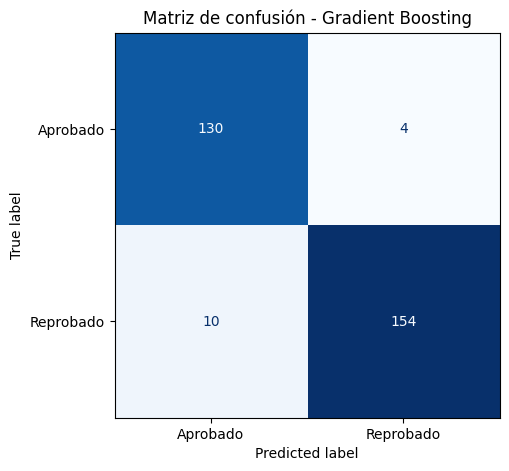


Interpretación:
- Verdaderos positivos: 154. Estudiantes reprobados correctamente identificados como riesgo.
- Falsos negativos: 10. Estudiantes reprobados que el modelo no detectó como riesgo.
- Verdaderos negativos: 130. Estudiantes aprobados correctamente clasificados.
- Falsos positivos: 4. Estudiantes aprobados marcados como riesgo.



In [ ]:
cm = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Aprobado", "Reprobado"]
)

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)
plt.title(f"Matriz de confusión - {modelo_final_nombre}")
plt.show()

tn, fp, fn, tp = cm.ravel()

print(f'''
Interpretación:
- Verdaderos positivos: {tp}. Estudiantes reprobados correctamente identificados como riesgo.
- Falsos negativos: {fn}. Estudiantes reprobados que el modelo no detectó como riesgo.
- Verdaderos negativos: {tn}. Estudiantes aprobados correctamente clasificados.
- Falsos positivos: {fp}. Estudiantes aprobados marcados como riesgo.
''')

### 11.2 Curva ROC

Evalúa la capacidad del modelo para separar ambas clases a distintos umbrales de decisión.

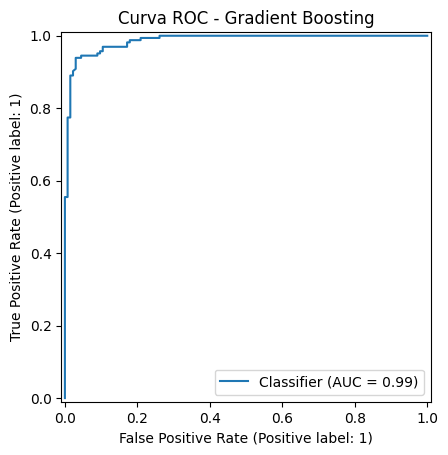

Interpretación: el ROC-AUC del modelo final es 0.9866. Un valor más cercano a 1 indica mejor separación entre aprobados y reprobados.


In [ ]:
if y_score_final is not None:
    RocCurveDisplay.from_predictions(y_test, y_score_final)
    plt.title(f"Curva ROC - {modelo_final_nombre}")
    plt.show()

    print(f"Interpretación: el ROC-AUC del modelo final es {roc_auc_score(y_test, y_score_final):.4f}. Un valor más cercano a 1 indica mejor separación entre aprobados y reprobados.")
else:
    print("El modelo final no genera probabilidades o scores; no se puede construir la curva ROC.")

### 11.3 Curva Precision-Recall

Es especialmente útil cuando interesa analizar la detección de la clase positiva: estudiantes en riesgo de reprobación.

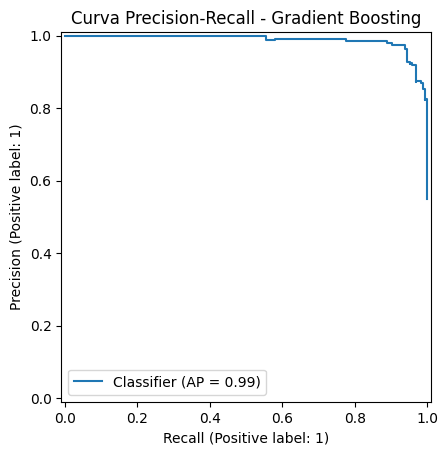

Interpretación: el Average Precision del modelo final es 0.9887. Este valor resume el equilibrio entre precision y recall para la clase de riesgo.


In [ ]:
if y_score_final is not None:
    PrecisionRecallDisplay.from_predictions(y_test, y_score_final)
    plt.title(f"Curva Precision-Recall - {modelo_final_nombre}")
    plt.show()

    print(f"Interpretación: el Average Precision del modelo final es {average_precision_score(y_test, y_score_final):.4f}. Este valor resume el equilibrio entre precision y recall para la clase de riesgo.")
else:
    print("El modelo final no genera probabilidades o scores; no se puede construir la curva Precision-Recall.")

### 11.4 Importancia de características

Se utiliza importancia nativa cuando el modelo la ofrece.  
Si no está disponible, se aplica **permutation importance**, que mide cuánto disminuye el rendimiento al alterar cada variable.

,Variable,Importancia
6,Promedio_Evaluaciones,0.8001
5,Tareas_y_Pruebas_Cortas,0.0722
8,Diferencia_Eval3_Eval1,0.0375
9,Ratio_Tareas_vs_Evaluaciones,0.0226
1,Promedio de ingreso,0.0146
7,Desviacion_Evaluaciones,0.0145
0,Año_lectivo,0.0127
3,Evaluación_2,0.0118
4,Evaluación_3,0.0079
2,Evaluación_1,0.0021


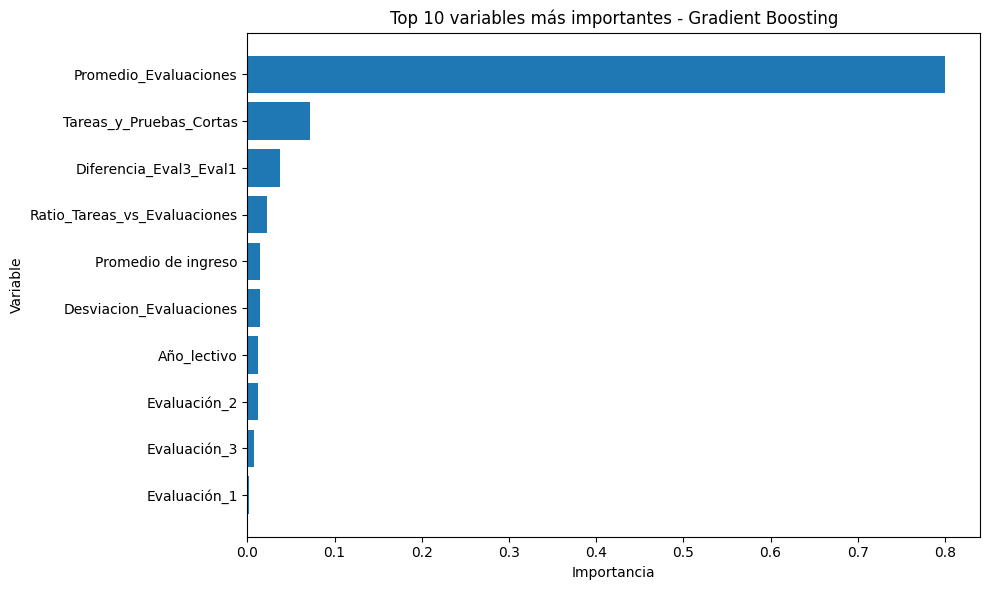


Interpretación:
Las variables con mayor importancia son las que más contribuyen a la clasificación del riesgo académico.
Estas variables deben revisarse pedagógicamente para identificar posibles puntos de intervención temprana.



In [ ]:
def obtener_importancias(modelo, X_test, y_test):
    if hasattr(modelo, "feature_importances_"):
        return pd.DataFrame({
            "Variable": X_test.columns,
            "Importancia": modelo.feature_importances_
        }).sort_values("Importancia", ascending=False)

    if hasattr(modelo, "coef_"):
        coef = np.abs(modelo.coef_).ravel()
        return pd.DataFrame({
            "Variable": X_test.columns,
            "Importancia": coef
        }).sort_values("Importancia", ascending=False)

    resultado_perm = permutation_importance(
        modelo,
        X_test,
        y_test,
        n_repeats=10,
        random_state=RANDOM_STATE,
        scoring="f1",
        n_jobs=-1
    )

    return pd.DataFrame({
        "Variable": X_test.columns,
        "Importancia": resultado_perm.importances_mean
    }).sort_values("Importancia", ascending=False)


importancias = obtener_importancias(modelo_final, X_test, y_test)
top_importancias = importancias.head(10)

display(top_importancias.round(4))

plt.figure(figsize=(10, 6))
plt.barh(top_importancias["Variable"][::-1], top_importancias["Importancia"][::-1])
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title(f"Top 10 variables más importantes - {modelo_final_nombre}")
plt.tight_layout()
plt.show()

print('''
Interpretación:
Las variables con mayor importancia son las que más contribuyen a la clasificación del riesgo académico.
Estas variables deben revisarse pedagógicamente para identificar posibles puntos de intervención temprana.
''')

### 11.5 Análisis de errores por probabilidad estimada

Este gráfico muestra cómo se distribuyen los aciertos y errores según la probabilidad estimada de reprobación.  
Ayuda a identificar si los errores ocurren principalmente en casos de incertidumbre.

,rango_probabilidad,error
0,"(-0.001, 0.1]",0.009524
1,"(0.1, 0.2]",0.285714
2,"(0.2, 0.3]",0.222222
3,"(0.3, 0.4]",0.666667
4,"(0.4, 0.5]",0.111111
5,"(0.5, 0.6]",0.000000
6,"(0.6, 0.7]",0.000000
7,"(0.7, 0.8]",0.166667
8,"(0.8, 0.9]",0.142857
9,"(0.9, 1.0]",0.014085


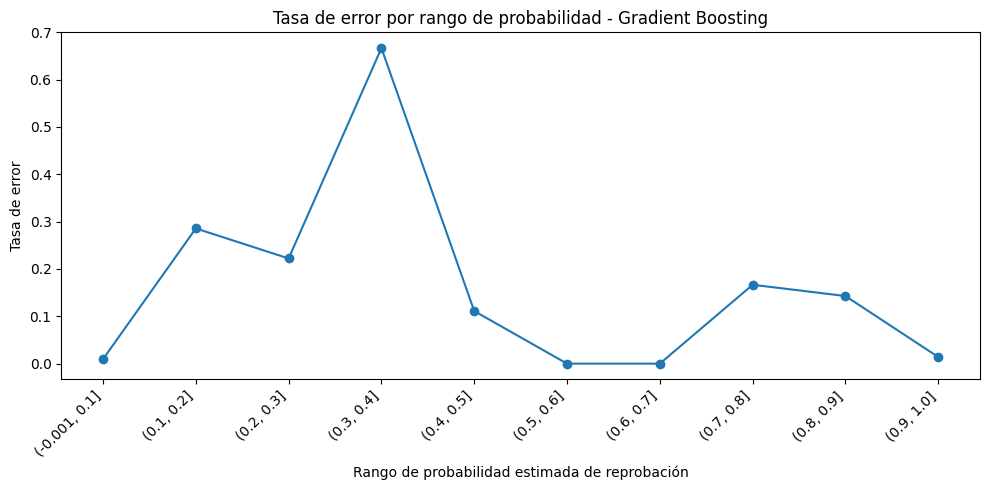


Interpretación:
Si la tasa de error es mayor en rangos intermedios, el modelo se equivoca principalmente cuando la probabilidad estimada está cerca del umbral de decisión.
Esto es esperable porque esos casos son más ambiguos y podrían requerir revisión docente o información adicional.



In [ ]:
analisis_errores = pd.DataFrame({
    "y_real": y_test.values,
    "y_pred": y_pred_final,
    "error": (y_test.values != y_pred_final).astype(int)
})

if y_score_final is not None:
    analisis_errores["probabilidad_reprobacion"] = y_score_final
    analisis_errores["rango_probabilidad"] = pd.cut(
        analisis_errores["probabilidad_reprobacion"],
        bins=np.linspace(0, 1, 11),
        include_lowest=True
    )

    errores_por_rango = analisis_errores.groupby("rango_probabilidad")["error"].mean().reset_index()
    errores_por_rango["rango_probabilidad"] = errores_por_rango["rango_probabilidad"].astype(str)

    display(errores_por_rango)

    plt.figure(figsize=(10, 5))
    plt.plot(errores_por_rango["rango_probabilidad"], errores_por_rango["error"], marker="o")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Tasa de error")
    plt.xlabel("Rango de probabilidad estimada de reprobación")
    plt.title(f"Tasa de error por rango de probabilidad - {modelo_final_nombre}")
    plt.tight_layout()
    plt.show()

    print('''
Interpretación:
Si la tasa de error es mayor en rangos intermedios, el modelo se equivoca principalmente cuando la probabilidad estimada está cerca del umbral de decisión.
Esto es esperable porque esos casos son más ambiguos y podrían requerir revisión docente o información adicional.
''')
else:
    print("El modelo final no genera probabilidades; se muestra resumen simple de errores.")
    display(analisis_errores["error"].value_counts(normalize=True).rename("proporción"))

### 11.6 Comparación visual de modelos

Este gráfico resume el desempeño de los modelos con la métrica principal y permite verificar si el modelo final supera a las alternativas evaluadas.

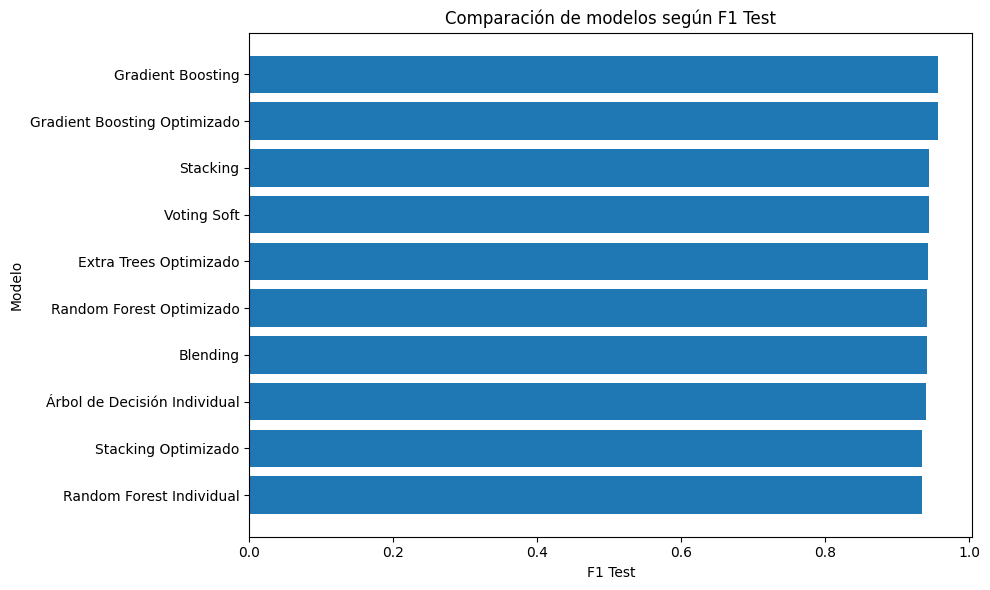


Interpretación:
El modelo ubicado en la parte superior de la tabla final y con mayor F1 Test representa la alternativa con mejor equilibrio entre precision y recall en datos no vistos.



In [ ]:
top_modelos = comparativa_final.head(10).copy()

plt.figure(figsize=(10, 6))
plt.barh(top_modelos["Modelo"][::-1], top_modelos["F1 Test"][::-1])
plt.xlabel("F1 Test")
plt.ylabel("Modelo")
plt.title("Comparación de modelos según F1 Test")
plt.tight_layout()
plt.show()

print('''
Interpretación:
El modelo ubicado en la parte superior de la tabla final y con mayor F1 Test representa la alternativa con mejor equilibrio entre precision y recall en datos no vistos.
''')

## 12. Conclusión general



## Conclusión General

En esta fase del proyecto se desarrolló una estrategia integral de modelado basada en técnicas de ensamble con el objetivo de maximizar la capacidad predictiva para identificar estudiantes con riesgo de reprobación. Para ello, se construyeron y evaluaron diversos modelos individuales y de ensamble, incluyendo Random Forest, Extra Trees, AdaBoost, Gradient Boosting, Voting Soft, Stacking y Blending. Asimismo, se realizó un proceso de optimización de hiperparámetros para los modelos más relevantes mediante validación cruzada.

La comparación de resultados se realizó utilizando el **F1-Score** como métrica principal, complementada con Accuracy, Recall, Precision, ROC-AUC, Average Precision, diferencia entre entrenamiento y prueba y tiempo de entrenamiento. Este enfoque permitió evaluar no solo el desempeño predictivo de cada modelo, sino también su capacidad de generalización y eficiencia computacional.

Los resultados obtenidos muestran que **Gradient Boosting** fue el modelo con mejor desempeño global, alcanzando un **F1-Score de 0.9565**, una exactitud del **95.3%**, un recall de **93.9%**, una precisión de **97.47%** y un ROC-AUC de **98.66%**. Estas métricas evidencian una excelente capacidad para identificar correctamente a los estudiantes en riesgo de reprobación, manteniendo simultáneamente una baja tasa de falsas clasificaciones.

Un aspecto relevante es que el modelo presentó una diferencia entre entrenamiento y prueba de únicamente **0.0131**, lo que indica una elevada capacidad de generalización y un riesgo reducido de sobreajuste. Adicionalmente, el tiempo de entrenamiento fue inferior a un segundo, demostrando una excelente relación entre desempeño predictivo y costo computacional.

La optimización de hiperparámetros permitió mejorar el rendimiento de algunos modelos, particularmente Random Forest y Extra Trees. Sin embargo, incluso después de la optimización, ninguno logró superar el desempeño alcanzado por Gradient Boosting. De igual manera, los ensambles heterogéneos como Voting, Stacking y Blending mostraron resultados competitivos, pero quedaron por debajo del modelo seleccionado.

Los análisis de importancia de variables indican que el desempeño académico acumulado, especialmente el **Promedio de Evaluaciones**, constituye el principal factor asociado a la aprobación o reprobación de los estudiantes, seguido por variables relacionadas con tareas, pruebas cortas y evaluaciones recientes. Esto confirma que el comportamiento académico continuo es el mejor predictor del resultado final.

En conclusión, el modelo **Gradient Boosting** fue seleccionado como modelo final debido a que logró el mejor equilibrio entre precisión, capacidad de detección, estabilidad y eficiencia computacional. Los resultados obtenidos demuestran que el modelo puede utilizarse como una herramienta confiable para apoyar estrategias de intervención temprana, permitiendo identificar estudiantes con mayor riesgo académico y facilitando la toma de decisiones orientadas a mejorar su desempeño y reducir los índices de reprobación.
